In [ ]:
import numpy as np
from tqdm import tqdm
from copy import deepcopy
from sklearn.base import clone
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

In [2]:
def cis_ensc_contribution(model, X, y, X_test, y_test):

    n_samples = X.shape[0]
    cis_values = np.zeros(n_samples)
    ensc_values = np.zeros(n_samples)

    y_pred_full = model.predict(X_test)
    full_mse = np.mean((y_test - y_pred_full)**2)

    for i in tqdm(range(n_samples)):
        X_reduced = np.delete(X, i, axis=0)
        y_reduced = np.delete(y, i, axis=0)
        temp_model = clone(model).fit(X_reduced, y_reduced)
        y_pred_reduced =  temp_model.predict(X_test)
        new_mse = np.mean((y_test - y_pred_reduced)**2)

        influence = full_mse - new_mse
        cis_values[i] = influence


    rem_cis = (full_mse - np.sum(cis_values)) / n_samples

    rem_ensc = [(full_mse - np.sum(cis_values) + cis_values[i]) / n_samples for i in range(n_samples)]

    print(rem_cis, rem_ensc )
    ensc_values = cis_values + np.array(rem_ensc)

    cis_values += rem_cis

    return cis_values, ensc_values

In [3]:
def train_and_evaluate(X_train, y_train, X_test, y_test, iterations=50):
    mse_test = []
    r2_test = []
    mse_train = []
    r2_train = []
    for i in range(iterations):
        model = HistGradientBoostingRegressor(max_iter=i+1)
        model.fit(X_train, y_train)

        y_pred_test = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        mse_test.append(mean_squared_error(y_test, y_pred_test))
        r2_test.append(r2_score(y_test, y_pred_test) * 100)

        mse_train.append(mean_squared_error(y_train, y_pred_train))
        r2_train.append(r2_score(y_train, y_pred_train) * 100)

    return mse_test, r2_test, mse_train, r2_train

In [4]:
def f(x):
    return x * 2 + 1

np.random.seed(42)
X = np.linspace(0,100,1000)
y = f(X)

noise = np.random.normal(0, 10, size=X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)
n_noise = 100
noise_idx = np.random.choice(np.arange(len(y_train)), replace=False, size=n_noise)
y_train[noise_idx] += noise[noise_idx]

In [5]:
rand_mse_test, rand_r2_test, rand_mse_train, rand_r2_train = np.zeros(100), np.zeros(100), np.zeros(100), np.zeros(100)
for i in tqdm(range(20)):
    indices = np.random.choice(len(X_train), 100, replace=False)
    X_train_rand, y_train_rand = X_train[indices], y_train[indices]
    mse_test, r2_test, mse_train, r2_train = train_and_evaluate(X_train_rand, y_train_rand, X_test, y_test, iterations=100)
    rand_mse_test, rand_r2_test, rand_mse_train, rand_r2_train = rand_mse_test + mse_test, rand_r2_test + r2_test, rand_mse_train + mse_train, rand_r2_train + r2_train
rand_mse_test /= 20
rand_r2_test /= 20
rand_mse_train /= 20
rand_r2_train  /= 20

100%|██████████| 20/20 [00:54<00:00,  2.73s/it]


In [6]:
model = HistGradientBoostingRegressor(max_iter=100)
model.fit(X_train, y_train)

HistGradientBoostingRegressor()

In [7]:
full_mse_test, full_r2_test, full_mse_train, full_r2_train = train_and_evaluate(X_train, y_train, X_test, y_test, iterations=100)

In [8]:
cis_values, ensc_values = cis_ensc_contribution(model, X_train, y_train, X_test, y_test)

100%|██████████| 800/800 [03:09<00:00,  4.21it/s]

-0.039750798761667594 [-0.0398576519574923, -0.03945957082666216, -0.039579354838004656, -0.03943347798368341, -0.03954488642563231, -0.039527922714435934, -0.039898569157970645, -0.039582183653633946, -0.03981759980795882, -0.03953074905412171, -0.03995789705024531, -0.03991661858485531, -0.0395876483998442, -0.039547688462756435, -0.03941768089827687, -0.03981983678946366, -0.039558154370687305, -0.03987305344311691, -0.03959505767366446, -0.039573736180001415, -0.039949691808219286, -0.03956170343080437, -0.03953933704632712, -0.03988561351773882, -0.03955360167858041, -0.039886308515581816, -0.039471982068546935, -0.039831314701036014, -0.03957455907623533, -0.03945660012854477, -0.039829173026025455, -0.039473682491427506, -0.03980652558724706, -0.03943273429508273, -0.0398728972895348, -0.03987367978853628, -0.03986037689605219, -0.03955877961063043, -0.0399029005296615, -0.03979370118118618, -0.03987758216969459, -0.03990394434684086, -0.03983381301149847, -0.0395447972685362, -

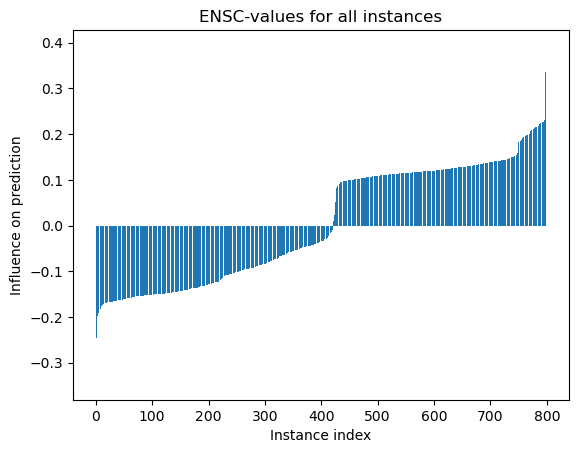

In [9]:
import matplotlib.pyplot as plt
plt.bar(range(len(ensc_values)), sorted(ensc_values))
plt.title("ENSC-values for all instances")
plt.xlabel("Instance index")
plt.ylabel("Influence on prediction")
plt.show()

In [12]:
top_indices = np.argsort(cis_values)[:100]
X_cis = X[top_indices].reshape(-1, 1)
y_cis = y[top_indices]

top_indices_1 = np.argsort(ensc_values)[:100]
X_ensc = X[top_indices_1].reshape(-1, 1)
y_ensc = y[top_indices_1]

In [13]:
cis_mse_test, cis_r2_test, cis_mse_train, cis_r2_train = train_and_evaluate(X_cis, y_cis, X_test, y_test, iterations=100)
ensc_mse_test, ensc_r2_test, ensc_mse_train, ensc_r2_train = train_and_evaluate(X_ensc, y_ensc, X_test, y_test, iterations=100)

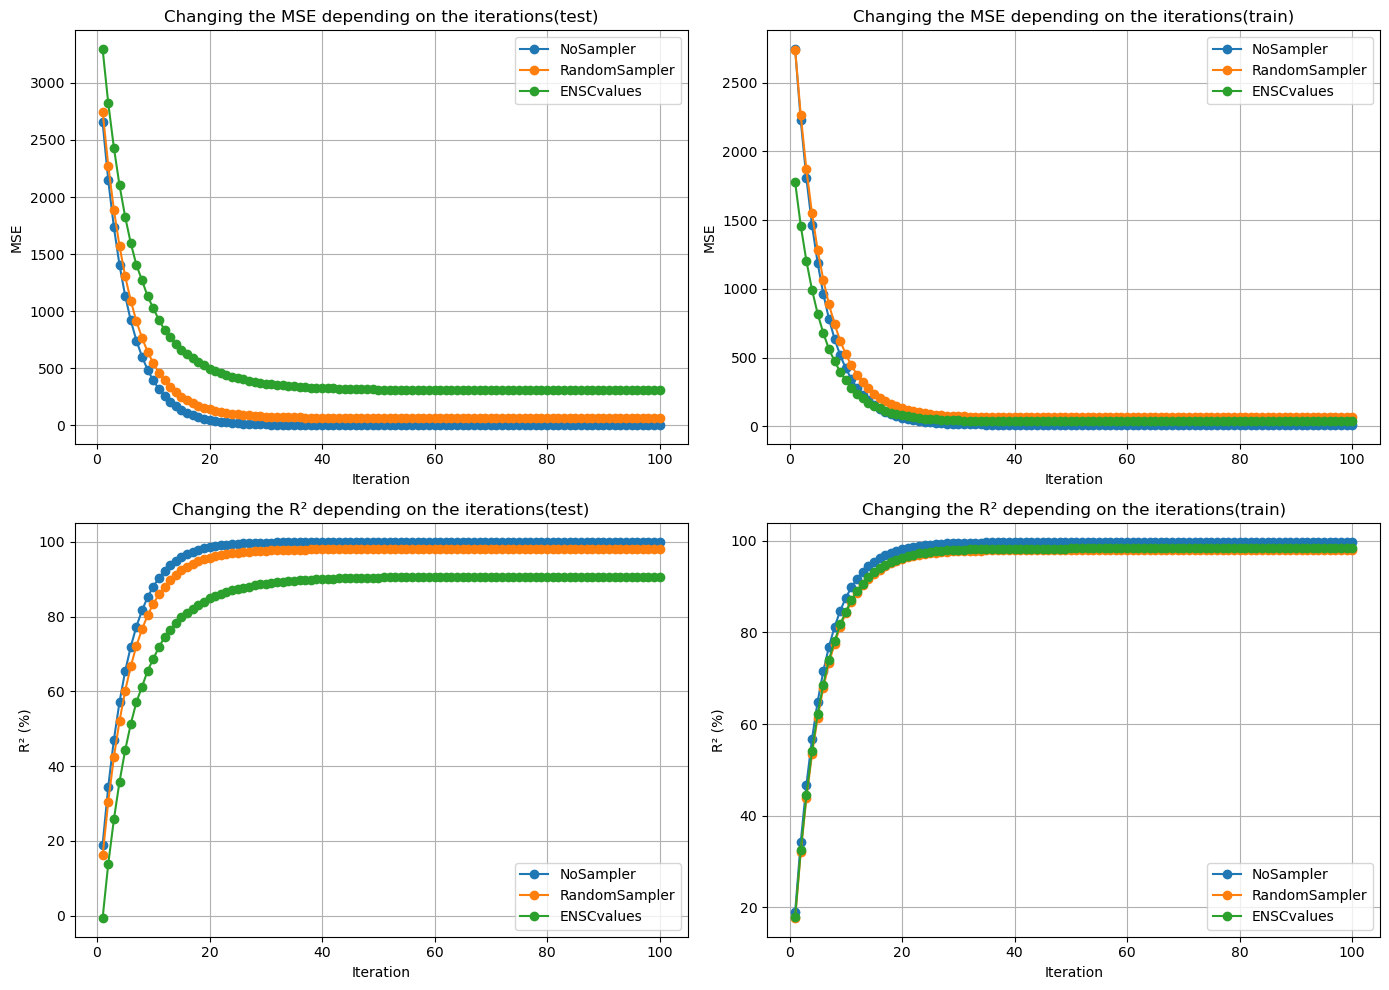

In [15]:
# Построим графики
plt.figure(figsize=(14, 10))

# График MSE для теста
plt.subplot(2, 2, 1)
plt.plot(range(1, 101), full_mse_test, label="NoSampler", marker="o")
plt.plot(range(1, 101), rand_mse_test, label="RandomSampler", marker="o")
plt.plot(range(1, 101), ensc_mse_test, label="ENSCvalues", marker="o")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Changing the MSE depending on the iterations(test)")
plt.legend()
plt.grid()

# График R² для теста
plt.subplot(2, 2, 3)
plt.plot(range(1, 101), full_r2_test, label="NoSampler", marker="o")
plt.plot(range(1, 101), rand_r2_test, label="RandomSampler", marker="o")
plt.plot(range(1, 101), ensc_r2_test, label="ENSCvalues", marker="o")
plt.xlabel("Iteration")
plt.ylabel("R² (%)")
plt.title("Changing the R² depending on the iterations(test)")
plt.legend()
plt.grid()

# График MSE для трейна
plt.subplot(2, 2, 2)
plt.plot(range(1, 101), full_mse_train, label="NoSampler", marker="o")
plt.plot(range(1, 101), rand_mse_train, label="RandomSampler", marker="o")
plt.plot(range(1, 101), ensc_mse_train, label="ENSCvalues", marker="o")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Changing the MSE depending on the iterations(train)")
plt.legend()
plt.grid()

# График R² для трейна
plt.subplot(2, 2, 4)
plt.plot(range(1, 101), full_r2_train, label="NoSampler", marker="o")
plt.plot(range(1, 101), rand_r2_train, label="RandomSampler", marker="o")
plt.plot(range(1, 101), cis_r2_train, label="ENSCvalues", marker="o")
plt.xlabel("Iteration")
plt.ylabel("R² (%)")
plt.title("Changing the R² depending on the iterations(train)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()